# Events that do not propagate: isolated downstream droughts and non-propagating upstream events

**Purpose.** Response analysis for **Reviewer #2, comment 3**: *"assess (a) upstream drought events that did not propagate downstream; and (b) downstream drought events that occurred without any upstream trigger."*

This reuses the validated, vectorised matching algorithm (`propagation_null_core.py` -- identical to the one behind the published 525 chains, validated in the R3.2 null-test analysis) **without modification**. It only adds two diagnostic passes:

- **(b) Isolated downstream events:** origin events receiving zero accepted upstream matches (complement of the published 56.6% connected fraction).
- **(a) Non-propagating upstream events:** among events that were ever a genuine, window-filtered candidate for at least one origin event, how many were never actually selected as the accepted match?

**Inputs:** `data/SSI_drought_events.csv`, `data/upstream_connectivity.csv`.
**Outputs:** `origin_events_connectivity_R2_3.csv`, `upstream_candidate_events_R2_3.csv`, `table_S3_unconnected_by_station.csv`, `fig_non_propagating_events.png/pdf`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, "..")  # shared modules live in revision_analyses/
from propagation_null_core import (W_DAYS, MIN_OVERLAP, build_station_arrays,
    parse_connectivity, run_matching_vectorized, summarise)
DATA, OUT = "data/", "./"

## 1. Load data and validate against the published numbers
Before any diagnostic pass, confirm the reused algorithm still reproduces the published 525/928 (56.6%) connected origin events -- the same validation performed for the R3.2 null test.

In [2]:
events = pd.read_csv(DATA+"SSI_drought_events.csv", parse_dates=["start_date","end_date","peak_date"])
connectivity = parse_connectivity(DATA+"upstream_connectivity.csv")
station_arr = build_station_arrays(events)
events_idx = events.set_index(["station_id","event_id"])
origin_stations = [sid for sid,ch in connectivity.items() if ch and sid in station_arr]

accepted_pairs = run_matching_vectorized(station_arr, connectivity)
stats = summarise(accepted_pairs, station_arr, connectivity)
print(f"{stats['n_chains']} / {stats['n_origin_events']} ({stats['connected_fraction']:.1f}%)")
assert stats["n_chains"]==525 and stats["n_origin_events"]==928
print("Validated.")

connected_origin_keys = {(o,e) for (o,e,u,ue,l) in accepted_pairs}
propagated_upstream_keys = {(u,ue) for (o,e,u,ue,l) in accepted_pairs}

525 / 928 (56.6%)
Validated.


## 2. Part (b) -- downstream origin events without an upstream trigger
For every origin event, record its own characteristics (duration, severity, intensity) and whether it received at least one accepted upstream match.

In [3]:
origin_rows=[]
for origin_sid in origin_stations:
    o = station_arr[origin_sid]
    for i in range(len(o["start"])):
        o_eid = int(o["eid"][i])
        row = events_idx.loc[(origin_sid,o_eid)]
        origin_rows.append(dict(origin_station=origin_sid, origin_event_id=o_eid,
            duration=row["duration"], severity=row["severity"], intensity=row["intensity"],
            connected=(origin_sid,o_eid) in connected_origin_keys))
origin_df = pd.DataFrame(origin_rows)
origin_df.to_csv(OUT+"origin_events_connectivity_R2_3.csv", index=False)

unconnected = origin_df[~origin_df.connected]; connected = origin_df[origin_df.connected]
print(f"Unconnected: {len(unconnected)}/{len(origin_df)} ({100*len(unconnected)/len(origin_df):.1f}%)")
print(f"Duration - connected: {connected.duration.mean():.1f} | unconnected: {unconnected.duration.mean():.1f}")
print(f"Severity - connected: {connected.severity.mean():.2f} | unconnected: {unconnected.severity.mean():.2f}")

Unconnected: 403/928 (43.4%)
Duration - connected: 35.1 | unconnected: 32.7
Severity - connected: 13.88 | unconnected: 11.22


### Per-station breakdown (Table S3)

In [4]:
by_station = origin_df.groupby("origin_station").agg(
    n_total=("connected","size"), n_unconnected=("connected", lambda x: (~x).sum()))
by_station["pct_unconnected"] = 100*by_station.n_unconnected/by_station.n_total
by_station = by_station.sort_values("pct_unconnected", ascending=False)
by_station.to_csv(OUT+"table_S3_unconnected_by_station.csv")
by_station

,n_total,n_unconnected,pct_unconnected
origin_station,,,
9004,109,85,77.981651
9036,89,69,77.528090
9101,35,26,74.285714
9038,52,38,73.076923
9096,59,43,72.881356
9065,86,45,52.325581
9025,82,42,51.219512
9120,71,27,38.028169
9005,79,21,26.582278


## 3. Part (a) -- upstream events that never propagate downstream
First identify every event that was ever a genuine, window-filtered candidate for at least one origin event (not just any event at an upstream-role station). Then check which of these were ever actually selected as an accepted match.

In [5]:
candidate_keys = set()
for origin_sid in origin_stations:
    upstream_sids = [s for s in connectivity[origin_sid] if s in station_arr]
    o = station_arr[origin_sid]
    for i in range(len(o["start"])):
        s_o = o["start"][i]; w_start = s_o - W_DAYS
        for up_sid in upstream_sids:
            u = station_arr[up_sid]
            mask = (u["end"]>=w_start)&(u["start"]<=s_o)
            for eid in u["eid"][mask]:
                candidate_keys.add((up_sid,int(eid)))

print(f"Ever a window-candidate for >=1 origin: {len(candidate_keys)}")
non_propagating = candidate_keys - propagated_upstream_keys
print(f"Never selected as accepted match: {len(non_propagating)} ({100*len(non_propagating)/len(candidate_keys):.1f}%)")

cand_rows=[]
for (sid,eid) in candidate_keys:
    row = events_idx.loc[(sid,eid)]
    cand_rows.append(dict(station_id=sid, event_id=eid, duration=row["duration"],
        severity=row["severity"], intensity=row["intensity"],
        propagated=(sid,eid) in propagated_upstream_keys))
cand_df = pd.DataFrame(cand_rows)
cand_df.to_csv(OUT+"upstream_candidate_events_R2_3.csv", index=False)

prop = cand_df[cand_df.propagated]; nonprop = cand_df[~cand_df.propagated]
print(f"Duration - propagated: {prop.duration.mean():.1f} | non-propagating: {nonprop.duration.mean():.1f}")
print(f"Severity - propagated: {prop.severity.mean():.2f} | non-propagating: {nonprop.severity.mean():.2f}")

Ever a window-candidate for >=1 origin: 1558
Never selected as accepted match: 602 (38.6%)


Duration - propagated: 54.3 | non-propagating: 19.3
Severity - propagated: 24.10 | non-propagating: 5.64


## 4. Publication figure
(a) % of isolated (unconnected) origin events by station; (b-c) duration/severity, connected vs unconnected origin events; (d-e) duration/severity, propagating vs non-propagating upstream events.

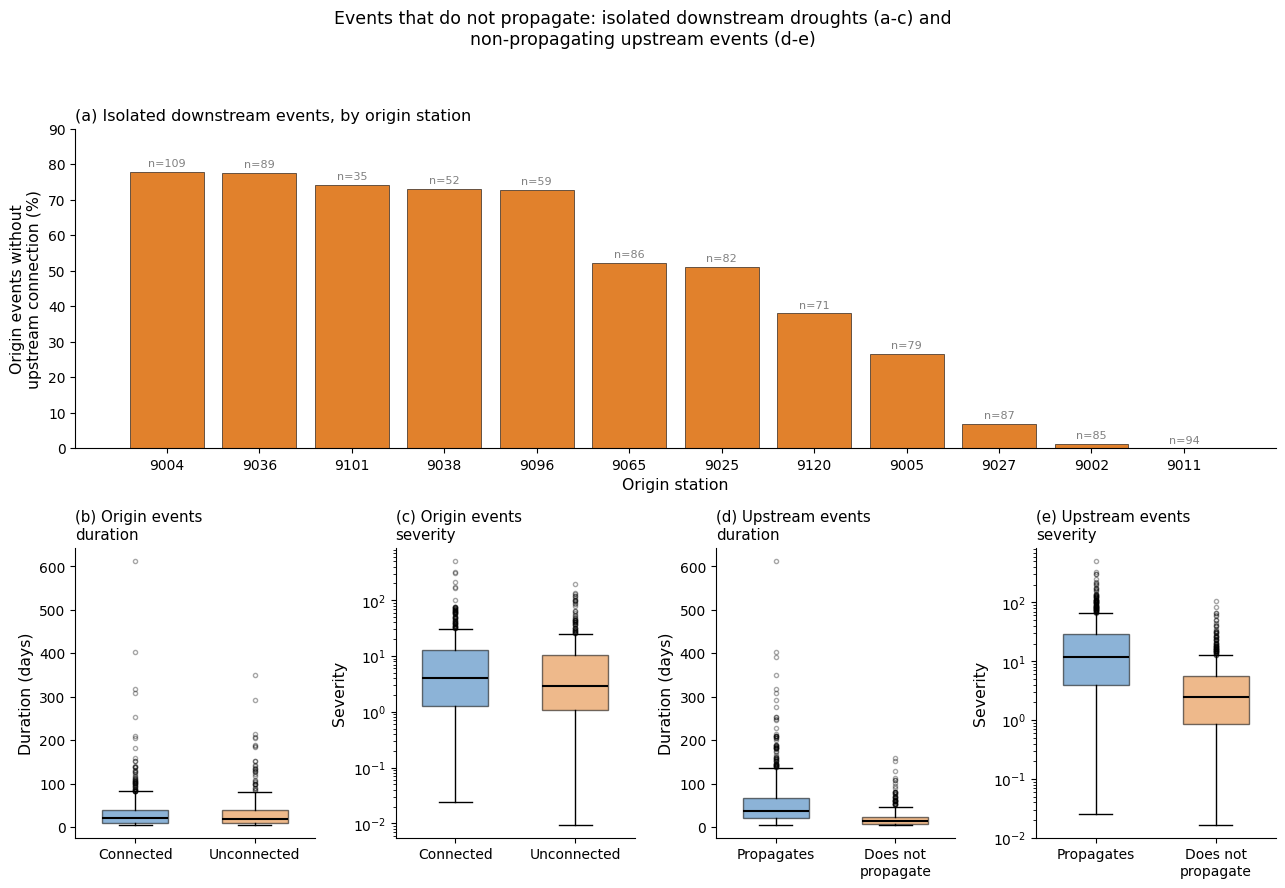

In [6]:
plt.rcParams.update({"font.size":11.5,"axes.titlesize":11.5,"axes.labelsize":11.3,
    "xtick.labelsize":10,"ytick.labelsize":10,"font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False})
BLUE,ORANGE = "#2E75B6","#E1812C"
fig = plt.figure(figsize=(13,8.6))
gs = fig.add_gridspec(2,4, height_ratios=[1.1,1])

ax_a = fig.add_subplot(gs[0,:])
stations = by_station.index.astype(str)
ax_a.bar(stations, by_station.pct_unconnected, color=ORANGE, edgecolor="k", linewidth=0.4)
ax_a.set_ylabel("Origin events without\nupstream connection (%)")
ax_a.set_xlabel("Origin station")
ax_a.set_title("(a) Isolated downstream events, by origin station", loc="left", fontsize=11.5)
for i,(n,pct) in enumerate(zip(by_station.n_total, by_station.pct_unconnected)):
    ax_a.text(i, pct+1.5, f"n={n}", ha="center", fontsize=8, color="grey")
ax_a.set_ylim(0,90)

def box_panel(ax, a, b, la, lb, ylabel, title, logscale=False):
    bp = ax.boxplot([a,b], tick_labels=[la,lb], patch_artist=True, widths=0.55,
                     showfliers=True, flierprops=dict(marker="o", markersize=3, alpha=0.35))
    for patch,color in zip(bp["boxes"], [BLUE,ORANGE]):
        patch.set_facecolor(color); patch.set_alpha(0.55)
    for m in bp["medians"]: m.set_color("black"); m.set_linewidth(1.5)
    if logscale: ax.set_yscale("log")
    ax.set_ylabel(ylabel); ax.set_title(title, loc="left", fontsize=10.8)

ax_b = fig.add_subplot(gs[1,0])
box_panel(ax_b, connected.duration, unconnected.duration, "Connected","Unconnected","Duration (days)","(b) Origin events\nduration")
ax_c = fig.add_subplot(gs[1,1])
box_panel(ax_c, connected.severity, unconnected.severity, "Connected","Unconnected","Severity","(c) Origin events\nseverity", logscale=True)
ax_d = fig.add_subplot(gs[1,2])
box_panel(ax_d, prop.duration, nonprop.duration, "Propagates","Does not\npropagate","Duration (days)","(d) Upstream events\nduration")
ax_e = fig.add_subplot(gs[1,3])
box_panel(ax_e, prop.severity, nonprop.severity, "Propagates","Does not\npropagate","Severity","(e) Upstream events\nseverity", logscale=True)

fig.suptitle("Events that do not propagate: isolated downstream droughts (a-c) and\n"
             "non-propagating upstream events (d-e)", fontsize=12.5, y=1.03)
fig.tight_layout()
fig.savefig(OUT+"fig_non_propagating_events.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT+"fig_non_propagating_events.pdf", bbox_inches="tight")
plt.show()

## 5. Interpretation

**Isolated downstream events (43.4% of origin events)** are only moderately less severe than connected ones -- many represent genuine local droughts, not negligible fluctuations. The probability of isolation varies enormously by station (0% at station 9011, with 22 upstream contributors, to 78% at station 9004), indicating that **network position**, not event characteristics, is the primary control on connectivity. Notably, the regulated station (9101, downstream of the Yesa reservoir) is among the most isolated (74.3%), consistent with the regulation-driven decoupling discussed elsewhere (response to Reviewer #4, Comment 3).

**Non-propagating upstream events (38.6% of genuine candidates)** are, by contrast, dramatically weaker than events that do propagate: roughly a third the duration and a quarter the severity. This is a reassuring, physically coherent result: the matching algorithm is not selecting propagation partners arbitrarily -- it preferentially identifies substantial, sustained upstream droughts as the drivers of downstream chains, consistent with the physical expectation that only sufficiently prolonged or severe deficits generate a detectable downstream signal.